# Binomial inflation correction — FRESH cohort re-run (gen9, bio1)

Per-record calibration of 4 binomial variants on the re-estimated (rerun_kfw_hb)
cohort. `binom` = plain full-N pool binomial (inflated baseline); `quasibinom` =
quasi-binomial φ-scaled Wald + K=16 (the **settled fix**); `betabinom` = beta-binomial
+ K=16; `effN_acer` = ACER coverage-based effective-N + K=16 (**dropped** — coverage is
not kMate's precision bottleneck). Decision metric = genomic inflation factor (GIF→1)
without flattening real peaks.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

GNP = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/gea_newpanel/results"
OUT = f"{GNP}/binom_fix_test_fresh"; import os; os.makedirs(OUT, exist_ok=True)
CLASSES = ["snp", "nonsnp"]
METHODS = ["binom", "quasibinom", "betabinom", "effN_acer"]
LABEL = {"binom": "plain full-N binomial (BASELINE, inflated)",
         "quasibinom": "quasi-binomial + K16 (SETTLED FIX)",
         "betabinom": "beta-binomial + K16",
         "effN_acer": "ACER effective-N + K16 (dropped)"}
COLORS = {"binom": "#7f7f7f", "quasibinom": "#2ca02c", "betabinom": "#1f77b4", "effN_acer": "#d62728"}
CHROMS = [f"Chr{i}" for i in range(1, 6)]; Q_FLOOR = 1e-16
# (file, pval-column) per method
SRC = {"binom":      (lambda c: f"{GNP}/quasibinom/quasibinom_lf16_{c}_gen9_bio1.csv", "pval_binom"),
       "quasibinom": (lambda c: f"{GNP}/quasibinom/quasibinom_lf16_{c}_gen9_bio1.csv", "pval_quasi"),
       "betabinom":  (lambda c: f"{GNP}/betabinom/betabinom_lf16_{c}_gen9_bio1.csv", "pval"),
       "effN_acer":  (lambda c: f"{GNP}/quasibinom/quasibinom_lf16_{c}_gen9_bio1.csv", "pval_effN")}

def load_raw(method, cls):
    f, col = SRC[method]
    d = pd.read_csv(f(cls), usecols=["chrom", "pos", "MAF", col]).rename(columns={col: "pval"})
    d = d[(d.MAF >= 0.05) & d.chrom.astype(str).isin(CHROMS) & d.pval.notna() & (d.pval > 0)].copy()
    d["chrom"] = d["chrom"].astype(str)
    return d

def gif(p):
    p = np.asarray(p, float); p = p[np.isfinite(p) & (p > 0)]
    return float(np.median(chi2.isf(p, 1)) / chi2.ppf(0.5, 1))

def bh_count_crit(p, q=0.05):
    v = np.sort(np.asarray(p, float)); m = len(v)
    ok = v <= q * np.arange(1, m + 1) / m
    k = int(np.flatnonzero(ok).max() + 1) if ok.any() else 0
    return k, (q * k / m if k else np.nan)

allpos = pd.concat([load_raw("binom", c)[["chrom", "pos"]] for c in CLASSES])
chrom_max = allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
GAP = 5e6; offset, off = {}, 0.0
for c in CHROMS: offset[c] = off; off += chrom_max[c] + GAP
ticks = [offset[c] + chrom_max[c] / 2 for c in CHROMS]
chrom_col = {c: ("#3b6fb0" if i % 2 == 0 else "#9bbce0") for i, c in enumerate(CHROMS)}
print("GIF:", {(m, c): round(gif(load_raw(m, c)["pval"]), 2) for m in METHODS for c in CLASSES})

GIF: {('binom', 'snp'): 17.04, ('binom', 'nonsnp'): 17.66, ('quasibinom', 'snp'): 3.24, ('quasibinom', 'nonsnp'): 3.32, ('betabinom', 'snp'): 2.27, ('betabinom', 'nonsnp'): 2.22, ('effN_acer', 'snp'): 1.31, ('effN_acer', 'nonsnp'): 1.31}


## QQ plot (raw per-record p, calibration)

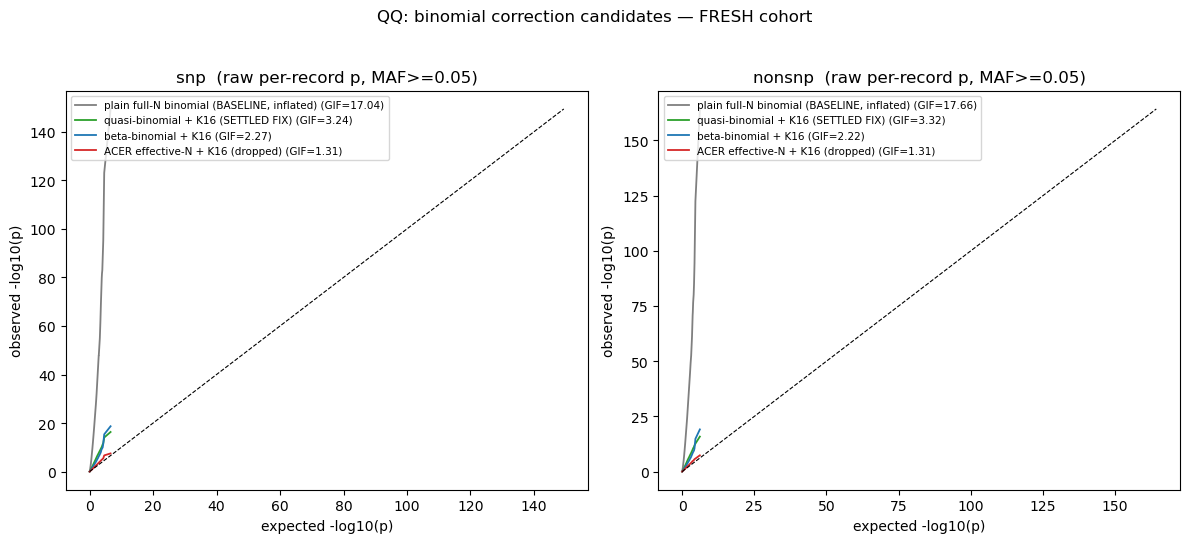

In [2]:
def qq_points(p, maxn=40000):
    p = np.sort(np.asarray(p, float)); p = p[np.isfinite(p) & (p > 0)]; n = len(p)
    exp = -np.log10((np.arange(1, n + 1) - 0.5) / n); obs = -np.log10(np.clip(p, 1e-320, 1))
    if n > maxn:
        idx = np.unique(np.r_[np.linspace(0, n - 1, maxn).astype(int), np.arange(n - 300, n)])
        exp, obs = exp[idx], obs[idx]
    return exp, obs
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, cls in zip(axes, CLASSES):
    mx = 0
    for m in METHODS:
        p = load_raw(m, cls)["pval"].to_numpy(); ex, ob = qq_points(p)
        ax.plot(ex, ob, color=COLORS[m], lw=1.3, label=f"{LABEL[m]} (GIF={gif(p):.2f})")
        mx = max(mx, ex.max(), ob.max())
    ax.plot([0, mx], [0, mx], "k--", lw=0.8)
    ax.set_xlabel("expected -log10(p)"); ax.set_ylabel("observed -log10(p)")
    ax.set_title(f"{cls}  (raw per-record p, MAF>=0.05)"); ax.legend(fontsize=7.5, loc="upper left")
fig.suptitle("QQ: binomial correction candidates — FRESH cohort", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95]); fig.savefig(f"{OUT}/qq_binom_fixcompare_fresh.png", dpi=140, bbox_inches="tight"); plt.show()

## Raw per-record Manhattan (pre-WZA)

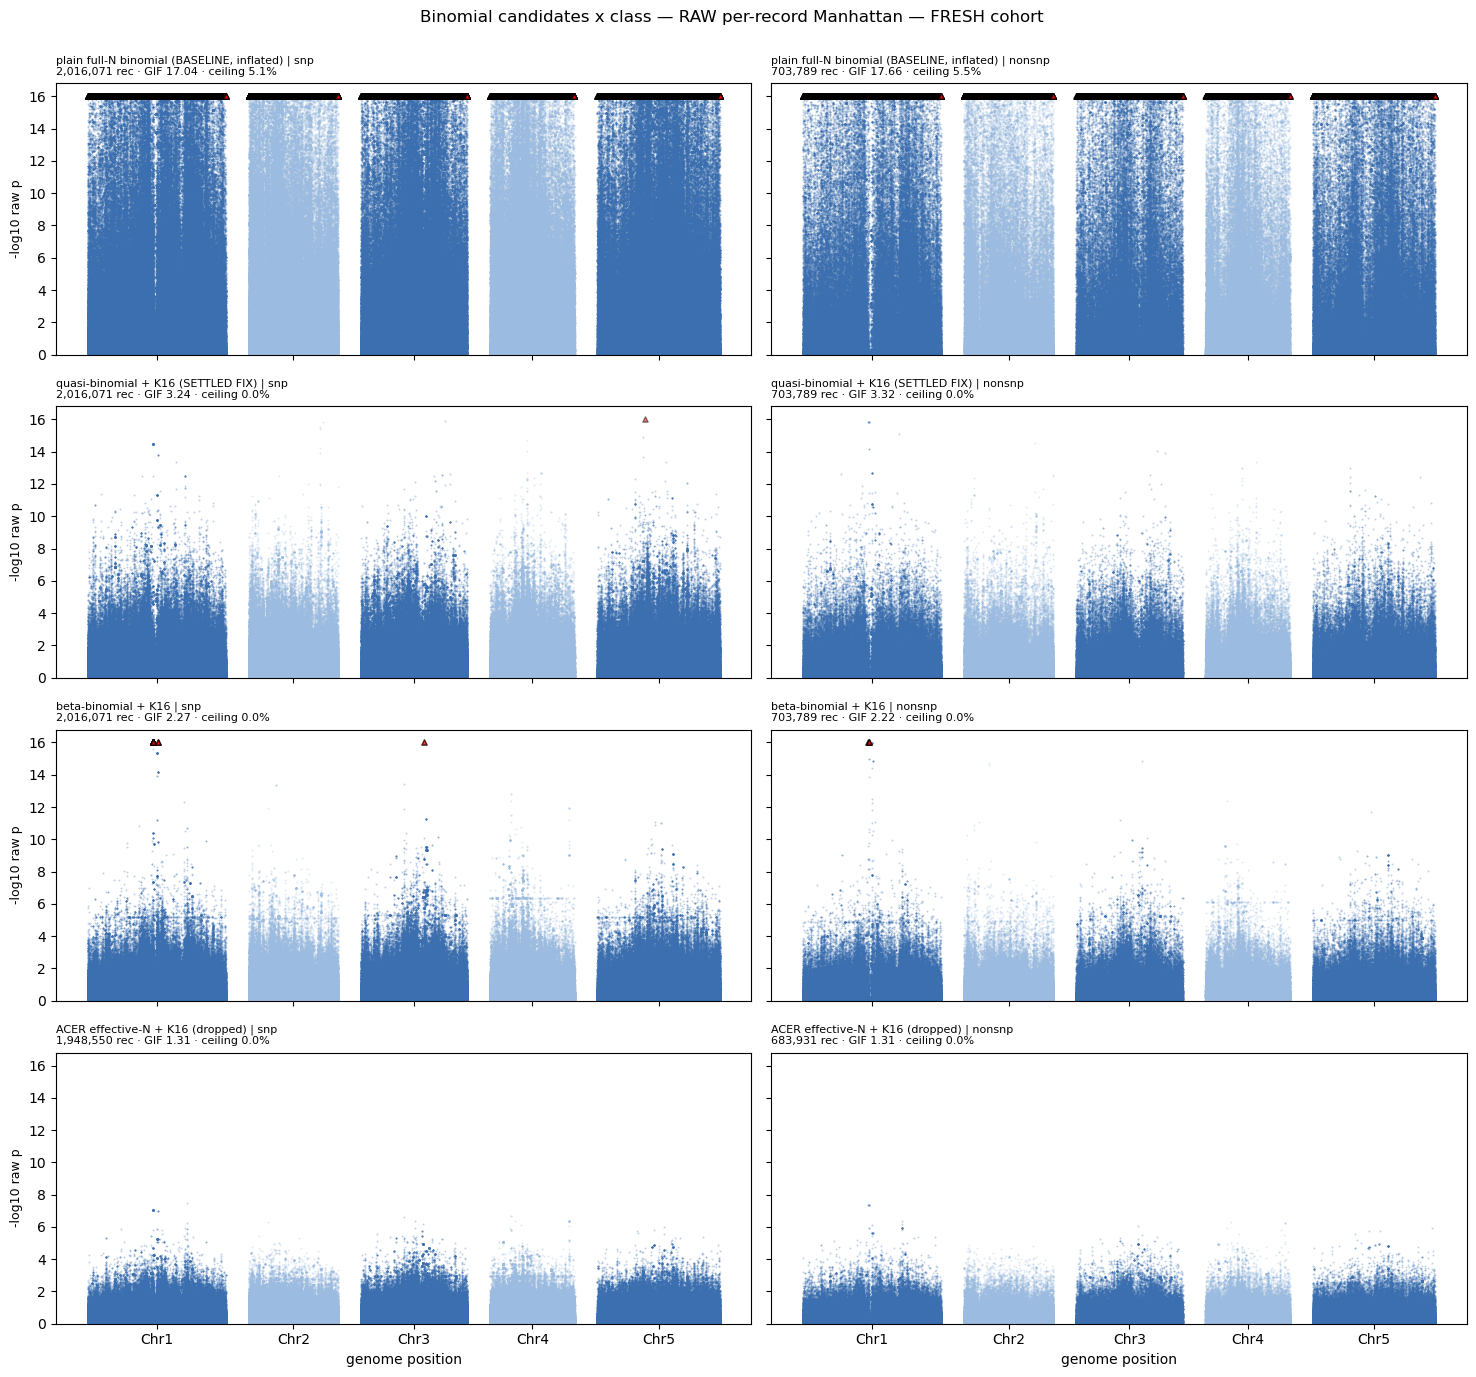

In [3]:
RAW_YMAX = -np.log10(Q_FLOOR)
fig, axes = plt.subplots(len(METHODS), len(CLASSES), figsize=(15, 14), sharex=True, sharey=True)
for r, m in enumerate(METHODS):
    for cc, cls in enumerate(CLASSES):
        ax = axes[r, cc]; d = load_raw(m, cls).copy(); d["x"] = d["pos"] + d["chrom"].map(offset)
        d["mlogp"] = -np.log10(d["pval"].clip(lower=Q_FLOOR)); n = len(d)
        ofs = d["pval"] < Q_FLOOR
        for c in CHROMS:
            mm = (d["chrom"] == c) & ~ofs
            ax.scatter(d["x"][mm], d["mlogp"][mm].clip(upper=RAW_YMAX), s=2, c=chrom_col[c], alpha=.3, linewidths=0, rasterized=True)
        if ofs.any():
            ax.scatter(d["x"][ofs], np.full(int(ofs.sum()), RAW_YMAX), marker="^", s=14, color="red", edgecolor="k", zorder=6, alpha=.5)
        ax.set_title(f"{LABEL[m]} | {cls}\n{n:,} rec · GIF {gif(d['pval']):.2f} · ceiling {ofs.mean():.1%}", fontsize=8, loc="left")
        if cc == 0: ax.set_ylabel("-log10 raw p", fontsize=9)
        ax.set_ylim(0, RAW_YMAX + 0.8)
for ax in axes[-1, :]:
    ax.set_xticks(ticks); ax.set_xticklabels(CHROMS); ax.set_xlabel("genome position")
fig.suptitle("Binomial candidates x class — RAW per-record Manhattan — FRESH cohort", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.98]); fig.savefig(f"{OUT}/manhattan_raw_binom_fixcompare_fresh.png", dpi=130, bbox_inches="tight"); plt.show()

## Summary (GIF, frac p<.05, per-record BH)

In [4]:
rows = []
for m in METHODS:
    for cls in CLASSES:
        d = load_raw(m, cls); p = d["pval"].to_numpy(); nbh, _ = bh_count_crit(p)
        rows.append(dict(method=m, cls=cls, n=len(d), gif=round(gif(p), 2),
                         frac_p05=round(float((p < 0.05).mean()), 3),
                         min_p=float(np.nanmin(p)), n_bh_perrec=nbh))
summary = pd.DataFrame(rows); summary.to_csv(f"{OUT}/binom_fixcompare_fresh_summary.csv", index=False)
print(summary.to_string(index=False)); summary

    method    cls       n   gif  frac_p05         min_p  n_bh_perrec
     binom    snp 2016071 17.04     0.633 3.962051e-150      1204926
     binom nonsnp  703789 17.66     0.639 5.900636e-165       425195
quasibinom    snp 2016071  3.24     0.278  4.807078e-17       266965
quasibinom nonsnp  703789  3.32     0.282  1.395048e-16        97548
 betabinom    snp 2016071  2.27     0.194  2.102536e-19        90156
 betabinom nonsnp  703789  2.22     0.193  7.886104e-20        30478
 effN_acer    snp 1948550  1.31     0.089  3.303041e-08           90
 effN_acer nonsnp  683931  1.31     0.090  4.401834e-08           48


,method,cls,n,gif,frac_p05,min_p,n_bh_perrec
0,binom,snp,2016071,17.04,0.633,3.962051e-150,1204926
1,binom,nonsnp,703789,17.66,0.639,5.900636e-165,425195
2,quasibinom,snp,2016071,3.24,0.278,4.807078e-17,266965
3,quasibinom,nonsnp,703789,3.32,0.282,1.395048e-16,97548
4,betabinom,snp,2016071,2.27,0.194,2.102536e-19,90156
5,betabinom,nonsnp,703789,2.22,0.193,7.886104e-20,30478
6,effN_acer,snp,1948550,1.31,0.089,3.303041e-08,90
7,effN_acer,nonsnp,683931,1.31,0.090,4.401834e-08,48
